In [5]:
from pathlib import Path
import os
import sys
from typing import Dict, Sequence, Optional

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

CWD = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CWD, *CWD.parents, CWD / "allhands_meeting" / "pcmdi_package"]:
    if (candidate / "scripts").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate pcmdi_package/scripts from the current working directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from metrics_group_merger import PCMDIRun


In [6]:
class ENSOPatternMapPlotter:
    """
    Plot 2D ENSO SST pattern maps for an observational reference and one or more model groups.

    Expects a data_dict with keys like:
      data_dict["reference"] : (lat, lon)
      data_dict["v3.LR.CPL"] : (lat, lon) or (member, lat, lon)
    """

    def __init__(
        self,
        data_dict: Dict[str, xr.DataArray],
        fig_dir: str,
        plot_dict: Dict[str, dict],
        group_order: Sequence[str] = ("v3.LR.CPL", "v3.HR.CPL", "v4P.CPL", "v4P.AMIP"),
        obs_key: str = "reference",
        lat_name: str = "latitude",
        lon_name: str = "longitude_a",
    ):
        """
        Parameters
        ----------
        data_dict : dict
            Mapping from group key to DataArray.
            Must contain obs_key and all groups in group_order.
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling information keyed by group name, e.g.
              {
                "reference": {"label": "ERA-Interim", "color": "black"},
                "v3.LR.CPL": {"label": "v3.LR.CPL"},
                "v3.HR.CPL": {"label": "v3.HR.CPL"},
              }
            Color is only used for titles/annotations; maps use cmap.
        group_order : sequence
            Model groups to plot after the reference.
        obs_key : str
            Key in data_dict for the observational reference.
        lat_name, lon_name : str
            Names of latitude and longitude coordinates in the DataArrays.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key
        self.lat_name    = lat_name
        self.lon_name    = lon_name

        # Build mean maps for each group (reference + ensemble means)
        self.mean_maps   = self._build_mean_maps()
        self.spread_maps = self._build_spread_maps()

    def _build_mean_maps(self) -> Dict[str, xr.DataArray]:
        """Return dict of 2D mean maps (lat, lon) for each key."""
        mean_maps = {}

        # ---- reference ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        ref = self.data_dict[self.obs_key]
        # average any extra dims beyond (lat, lon)
        extra_dims = [d for d in ref.dims if d not in (self.lat_name, self.lon_name)]
        if extra_dims:
            ref = ref.mean(dim=extra_dims)
        mean_maps[self.obs_key] = ref

        # ---- model groups ----
        for key in self.group_order:
            if key not in self.data_dict:
                raise ValueError(
                    f"Expected group '{key}' in data_dict, "
                    f"found keys: {list(self.data_dict.keys())}"
                )
            da = self.data_dict[key]
            # average over member and any extra dims beyond (lat, lon)
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if extra_dims:
                da = da.mean(dim=extra_dims)
            mean_maps[key] = da

        return mean_maps

    def _build_spread_maps(self) -> Dict[str, xr.DataArray]:
        """
        Return dict of ensemble spread (std) maps (lat, lon) for each model group.
        Reference/obs is omitted because it has no ensemble.
        """
        spread_maps = {}
        for key in self.group_order:
            if key not in self.data_dict:
                continue
            da = self.data_dict[key]

            # Treat any non-lat/lon dims (e.g., 'member', 'sample') as ensemble/sample dims
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if not extra_dims:
                # No ensemble dimension -> no spread
                continue

            spread_maps[key] = da.std(dim=extra_dims)
        return spread_maps

    def _get_panel_label(self, key: str) -> str:
        """Get human-readable label for each panel from plot_dict or the key."""
        style = self.plot_dict.get(key, {})
        return style.get("label", key)

    def _area_weights_like(self, da: xr.DataArray) -> xr.DataArray:
        """Return cosine-latitude weights broadcast to a map DataArray."""
        lat = da[self.lat_name]
        weights = xr.DataArray(
            np.cos(np.deg2rad(lat)),
            coords={self.lat_name: lat},
            dims=(self.lat_name,),
        )
        return weights.broadcast_like(da)

    def _weighted_rmse(self, model: xr.DataArray, ref: xr.DataArray) -> float:
        model, ref = xr.align(model, ref, join="inner")
        weights = self._area_weights_like(model)
        valid = np.isfinite(model) & np.isfinite(ref) & np.isfinite(weights)
        if not bool(valid.any()):
            return np.nan
        diff2 = ((model - ref) ** 2).where(valid)
        weights = weights.where(valid)
        return float(np.sqrt(diff2.weighted(weights).mean()))

    def _weighted_pcor(self, model: xr.DataArray, ref: xr.DataArray) -> float:
        model, ref = xr.align(model, ref, join="inner")
        weights = self._area_weights_like(model)
        valid = np.isfinite(model) & np.isfinite(ref) & np.isfinite(weights)
        if not bool(valid.any()):
            return np.nan
        model = model.where(valid)
        ref = ref.where(valid)
        weights = weights.where(valid)
        model_anom = model - model.weighted(weights).mean()
        ref_anom = ref - ref.weighted(weights).mean()
        covariance = (model_anom * ref_anom).weighted(weights).mean()
        model_std = np.sqrt((model_anom ** 2).weighted(weights).mean())
        ref_std = np.sqrt((ref_anom ** 2).weighted(weights).mean())
        denom = model_std * ref_std
        if float(denom) == 0.0:
            return np.nan
        return float(covariance / denom)

    def _annotate_reference_metrics(self, ax, model: xr.DataArray, ref: xr.DataArray, fontz: int):
        rmse = self._weighted_rmse(model, ref)
        pcor = self._weighted_pcor(model, ref)
        ax.text(
            0.98,
            0.03,
            f"RMSE={rmse:.2f}\nPCOR={pcor:.2f}",
            transform=ax.transAxes,
            fontsize=fontz * 0.78,
            va="bottom",
            ha="right",
            bbox=dict(
                facecolor=(1.0, 1.0, 1.0, 0.70),
                edgecolor="black",
                linewidth=0.5,
                boxstyle="round,pad=0.25",
            ),
        )

    def plot_sst_map(
        self,
        filename: str = "enso_sst_pattern_four_models.pdf",
        cmap: str = "RdBu_r",
        mlevels: Optional[list] = None,
        title_prefix: str = "",
        figsize: tuple = (14, 3.5),
        fontz: int = 12,
        central_lon: float = 180.0,
        overlay_spread: bool = False,
        spread_quantile: float = 0.75,
        spread_level: float = None,
        fig_idx: int = 0,
    ):
        """
        Plot 3-panel ENSO SST pattern comparison with optional ensemble-spread overlay.
        """
        panel_keys = [self.obs_key] + list(self.group_order)
        maps = [self.mean_maps[k] for k in panel_keys]

        lat = maps[0][self.lat_name].values
        lon = maps[0][self.lon_name].values

        # tick locations
        xticks = np.arange(np.floor(lon.min()), np.ceil(lon.max()), 30)
        yticks = np.arange(-15, 16, 10)

        # ----- Determine color limits -----
        if mlevels is None:
            all_vals = np.concatenate([m.values.ravel() for m in maps])
            finite = np.isfinite(all_vals)
            max_abs = np.nanmax(np.abs(all_vals[finite]))
            vmin = -max_abs
            vmax = max_abs
            # levels for pattern contours
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min (mlevels) 
            vmax = max (mlevels) 
        
        # ----- Determine spread contour levels (if overlay is requested) -----
        if overlay_spread and self.spread_maps:
            if spread_level is None:
                all_spread_vals = np.concatenate([
                    self.spread_maps[k].values.ravel()
                    for k in self.group_order
                    if k in self.spread_maps
                ])
                finite = np.isfinite(all_spread_vals)
                if np.any(finite):
                    spread_level = np.nanpercentile(
                        all_spread_vals[finite],
                        spread_quantile * 100.0,
                    )

        # ----- Setup figure -----
        fig = plt.figure(figsize=figsize)
        n = len(panel_keys)

        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        axes = []
        for i, key in enumerate(panel_keys):
            ax = fig.add_subplot(1, n, i + 1, projection=proj)
            ax.set_aspect("auto")
            axes.append(ax)   # <<< IMPORTANT: add axis to list

            da_map = self.mean_maps[key]
            label = self._get_panel_label(key)

            # Filled contour map instead of pcolormesh
            im = ax.contourf(
                lon, lat, da_map,
                levels=mlevels,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                transform=data_crs,
                extend="both",
            )

            # (optional but nice) thin contour outlines
            ax.contour(
                lon, lat, da_map,
                levels=mlevels,
                colors="k",
                linewidths=0.3,
                transform=data_crs,
            )

            ax.coastlines(linewidth=0.5)
            ax.set_extent(
                [lon.min(), lon.max(), lat.min(), lat.max()],
                crs=data_crs,
            )

            # Latitude / longitude ticks and labels
            ax.set_xticks(xticks, crs=data_crs)
            ax.set_yticks(yticks, crs=data_crs)
            ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f"))
            ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f"))
            
            # --- optional: overlay ensemble spread as hatched dots ---
            if overlay_spread and key in self.spread_maps:
                spread = self.spread_maps[key]
                
                if spread_level is not None:
                    # mask below threshold
                    spread_mask = np.where(spread > spread_level, 1, np.nan)
            
                    ax.contourf(
                        lon, lat, spread_mask,
                        levels=[0.5, 1.5],      # two levels: masked vs hatched
                        hatches=["...."],       # dotted hatching
                        colors="none",          # no fill color
                        transform=data_crs,
                    )

            if key != self.obs_key:
                self._annotate_reference_metrics(ax, da_map, self.mean_maps[self.obs_key], fontz)

            panel_label = f"({chr(97 + i + fig_idx)}) {label}"
            ax.set_title(panel_label, fontsize=fontz * 1.0, loc="left")
            ax.tick_params(labelsize=fontz * 0.95)

            if i == 0:
                ax.set_ylabel("Latitude", fontsize=fontz * 1.0)
            ax.set_xlabel("Longitude", fontsize=fontz * 1.0)

        # ----- Colorbar (centered below all panels) -----
        cbar = fig.colorbar(
            im,
            ax=axes,  # now non-empty
            orientation="horizontal",
            fraction=0.05,
            pad=0.12,
            aspect=40,
        )

        cbar.set_label("SST pattern (deg C)", fontsize=fontz * 1.0)
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        # Manual layout to avoid big white space and keep room for colorbar
        fig.subplots_adjust(
            left=0.06,
            right=0.98,
            bottom=0.2,
            top=0.82,
            wspace=0.15,
        )

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=150, format="pdf")
        print(f"Saved ENSO SST pattern map figure to {out_path}")
        return fig, axes
        
    def plot_multi_sst_map(
        self,
        other_plotter,
        var_labels=None,
        filename="enso_sst_pattern_multi.pdf",
        figsize=(15, 8),
        fontz=14,
        cmap="RdBu_r",
        mlevels=None,
        central_lon=180.0,
        overlay_spread=True,
        spread_quantile=0.75,
        spread_level=0.1,
        fig_idx_start=0,
        fig_aspect=0.45,
        fig_format="pdf",
        fig_dpi=300,
        cb_label="SST pattern (deg C)",
    ):
        """
        Plot self and another plotter together.

        Row 1 = self
        Row 2 = other_plotter
        """
        # both plotters must share lat/lon
        panel_keys = [self.obs_key] + list(self.group_order)
        ncols = len(panel_keys)
        nrows = 2

        # lat/lon
        lat = self.mean_maps[self.obs_key][self.lat_name].values
        lon = self.mean_maps[self.obs_key][self.lon_name].values

        if mlevels is None:
            # gather values for global color limits
            all_vals = []
            for mp in [self, other_plotter]:
                for key in panel_keys:
                    all_vals.append(mp.mean_maps[key].values.ravel())
            all_vals = np.concatenate(all_vals)
            finite = np.isfinite(all_vals)
            vmax = np.nanmax(np.abs(all_vals[finite]))
            vmin = -vmax
            mlevels = np.linspace(vmin, vmax, 17)
        else:
            vmin = min (mlevels) 
            vmax = max (mlevels) 
        
        # ticks
        xticks = np.arange(np.floor(lon.min()), np.ceil(lon.max()), 30)
        yticks = np.arange(-10, 11, 10)

        # create figure
        fig = plt.figure(figsize=figsize)
        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        # loop rows
        plotters = [self, other_plotter]
        axes = []
        im = None
        
        # build cmap with distinct extension colors
        base_cmap = plt.get_cmap(cmap).copy()
        base_cmap.set_under("#08306B")   # deep navy for < vmin
        base_cmap.set_over("#67000D")    # deep maroon for > vmax

        for row in range(nrows):
            mp = plotters[row]
            for col, key in enumerate(panel_keys):
                idx = row * ncols + col + 1
                ax = fig.add_subplot(nrows, ncols, idx, projection=proj)
                ax.set_aspect("auto")        # keep data aspect free
                ax.set_box_aspect(fig_aspect)  # FIX panel shape independent of figsize
                axes.append(ax)
                da_map = mp.mean_maps[key]

                # filled contours
                im = ax.contourf(
                    lon, lat, da_map,
                    levels=mlevels,
                    cmap=base_cmap,
                    vmin=vmin, vmax=vmax,
                    transform=data_crs,
                    extend="both",
                )

                # thin outlines
                ax.contour(
                    lon, lat, da_map,
                    levels=mlevels,
                    colors="k",
                    linewidths=0.3,
                    transform=data_crs,
                )

                ax.coastlines(linewidth=0.5)
                ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=data_crs)

                # ticks
                ax.set_yticks(yticks, crs=data_crs)
                ax.set_xticks(xticks, crs=data_crs)
                ax.xaxis.set_major_formatter(LongitudeFormatter(".0f"))
                ax.yaxis.set_major_formatter(LatitudeFormatter(".0f"))

                # spread hatching
                if overlay_spread and key in mp.spread_maps:
                    spread = mp.spread_maps[key]
                
                    if spread_level is None:
                        vals = spread.values                 # <- go to numpy
                        finite = np.isfinite(vals)
                        if np.any(finite):
                            spread_level = np.nanpercentile(
                                vals[finite],
                                spread_quantile * 100.0,
                            )
                
                    spread_mask = np.where(spread.values > spread_level, 1, np.nan)
                    ax.contourf(
                        lon, lat, spread_mask,
                        levels=[0.5, 1.5],
                        hatches=["...."],
                        colors="none",
                        transform=data_crs,
                    )
                    
                if key != mp.obs_key:
                    mp._annotate_reference_metrics(ax, da_map, mp.mean_maps[mp.obs_key], fontz)

                # panel label (a, b, c, d, e, f)
                label = mp._get_panel_label(key)
                panel_label = f"({chr(fig_idx_start + idx - 1 + 97)}) {label}"
                ax.set_title(panel_label, fontsize=fontz, loc="left")
                ax.set_title(f"{var_labels[row]}",fontsize=fontz, loc="right")
                ax.tick_params(labelsize=fontz * 0.95)

                if col == 0:
                    ax.set_ylabel("Latitude", fontsize=fontz)
                ax.set_xlabel("Longitude", fontsize=fontz)

        fig.subplots_adjust(
            left=0.06,
            right=0.98,
            bottom=0.23,      # more room so cb sits lower
            top=0.92,
            hspace=0.10,      # reduce space between rows
            wspace=0.18,
        )
        # ---------------------------------------
        # 2. Dedicated vertical colorbar axis
        #    [left, bottom, width, height] in figure coords
        # ---------------------------------------
        cax = fig.add_axes([1.0, 0.35, 0.015, 0.50])
        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical",
            fraction=0.01,
            pad=0.04,
            aspect=40,
        )        
        cbar.set_label(cb_label, fontsize=fontz)
        cbar.set_ticks(mlevels)
        cbar.set_ticklabels([f"{lv:g}" for lv in mlevels])
        cbar.ax.tick_params(labelsize=fontz * 0.95)

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format,
                    bbox_inches="tight", pad_inches=0.05)
        
        print("Saved:", out_path)


Resolved ENSO pattern files:
  v3.LR.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20231209.v3.LR.piControl-spinup.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_tel/e3sm_historical_ENSO_tel_v20260531_EAMXX-ne256_coupled-test_EnsoSstLonRmse.nc
  v3.HR.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_tel/e3sm_historical_ENSO_tel_v20260601_v3-HR_test6-1_EnsoSstLonRmse.nc
  v4P.CPL: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/20260204.ne256.WCYCLXX1850.SOI/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_tel/e3sm_historical_ENSO_tel_v20260601_EAMXX-ne256_coupled-test_EnsoSstLonRmse.nc
  v4P.AMIP: /global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_tel/e3sm_amip_ENSO_tel_v20260531_EAMXX_test2_1_EnsoSstLonRmse

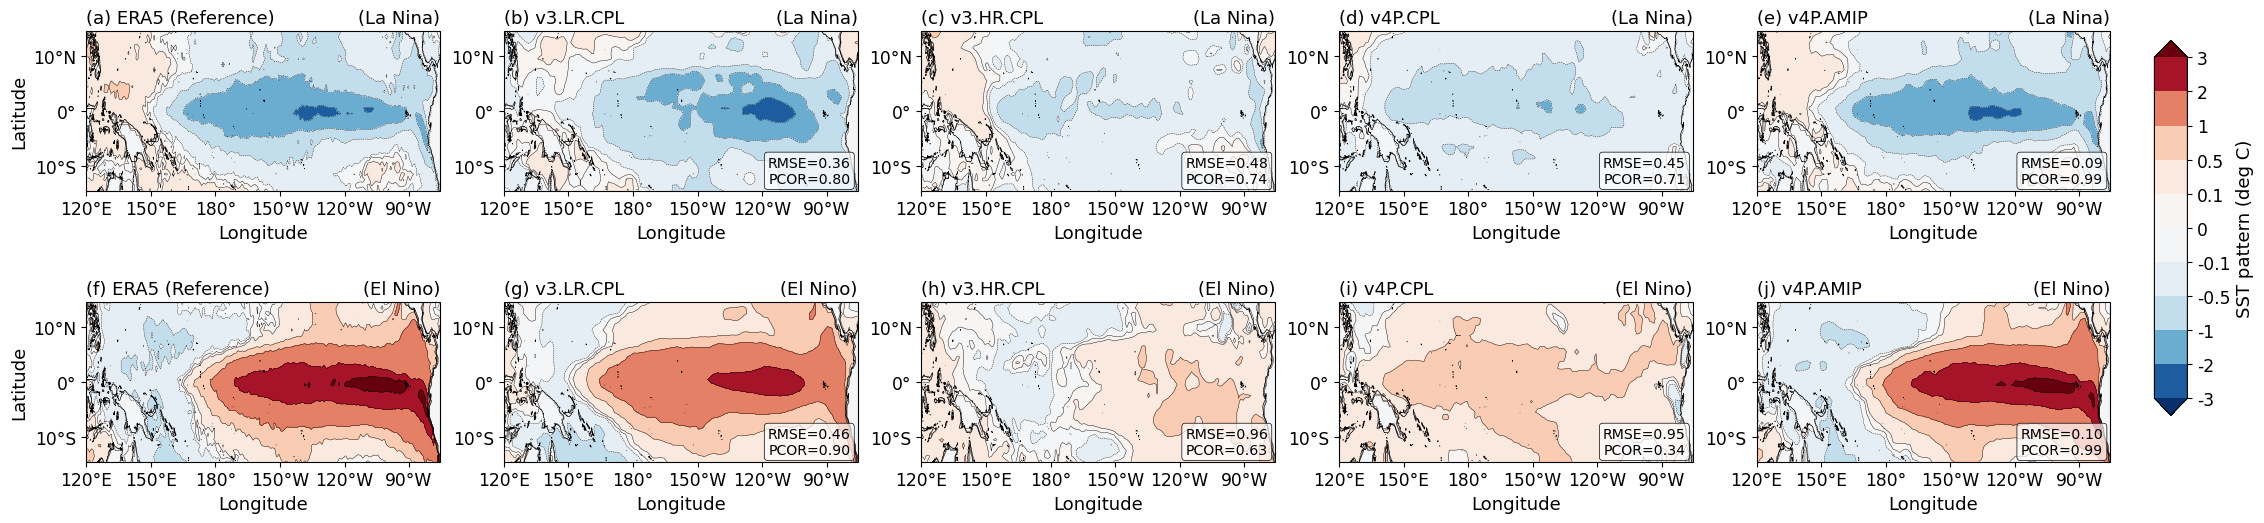

In [7]:
# Four-model ENSO SST-pattern comparison. This mirrors plot_2d_map.ipynb.
OUTPUT_DIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi/analysis_output/enso_pattern_maps")
RUN_TYPE = "model_vs_obs"
RUN_PLOTS = True
STRICT_PATHS = False

TARGET_GROUP = "ENSO_tel"
TARGET_METRIC = "enso_sst_lon_rmse"
TARGET_SUFFIX = "EnsoSstLonRmse"
TARGET_VARIABLES = ["Nina_sst_map", "Nino_sst_map"]
VAR_LABELS = {
    "Nina_sst_map": "(La Nina)",
    "Nino_sst_map": "(El Nino)",
}
OBS_KEY = "reference"
OBS_LABEL = "ERA5"
OBS_TAG = "ERA5"
LAT_NAME = "latitude"
LON_NAME = "longitude_a"

FIGURE_NAME = f"enso_{TARGET_METRIC}_four_models_maps.pdf"
FIGURE_FORMAT = "pdf"
FIGURE_DPI = 300
FIGSIZE = (22, 7.5)
FONTZ = 13
LEVELS = [-3, -2, -1, -0.5, -0.1, 0, 0.1, 0.5, 1, 2, 3]
OVERLAY_SPREAD = False
SPREAD_QUANTILE = 0.75
SPREAD_LEVEL = None

TEST_RUNS = [
    PCMDIRun(
        case="20231209.v3.LR.piControl-spinup.chrysalis",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260531",
        output_name="v3.LR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20250906.wcycl1850.ne120pg2_r025_RRSwISC6to18E3r5.test6.1.chrysalis",
        model_name="v3-HR_test6-1",
        metrics_case_id="v20260601",
        output_name="v3.HR.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="20260204.ne256.WCYCLXX1850.SOI",
        model_name="EAMXX-ne256_coupled-test",
        metrics_case_id="v20260601",
        output_name="v4P.CPL",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
    PCMDIRun(
        case="ne256pg2_ne256pg2.F20TR-SCREAMv1.July-1.spanc800.2xauto.acc150.n0032.test2.1",
        model_name="EAMXX_test2_1",
        metrics_case_id="v20260531",
        output_name="v4P.AMIP",
        www=Path("/global/cfs/cdirs/e3sm/www/zhan391/eamxx-pcmdi"),
    ),
]

GROUP = [run.output_name for run in TEST_RUNS]
PLOT_DICT = {
    OBS_KEY: {"label": f"{OBS_LABEL} (Reference)"},
    **{run.output_name: {"label": run.output_name} for run in TEST_RUNS},
}


def find_enso_metric_file(run: PCMDIRun, enso_group: str, suffix: str) -> Path:
    enso_dir = run.www / run.case / "pcmdi_diags" / RUN_TYPE / "metrics_data" / "enso_metric" / enso_group
    pattern = f"*_{enso_group}_{run.metrics_case_id}_{run.model_name}_{suffix}.nc"
    matches = sorted(enso_dir.glob(pattern))
    if not matches:
        fallback_pattern = f"*{run.metrics_case_id}*{suffix}.nc"
        matches = sorted(enso_dir.glob(fallback_pattern))
    if not matches:
        message = f"No ENSO metric file found for {run.output_name}: {enso_dir} / {pattern}"
        if STRICT_PATHS:
            raise FileNotFoundError(message)
        print(f"[WARN] {message}")
        return None
    if len(matches) > 1:
        print(f"[WARN] Multiple files matched {run.output_name}; using {matches[-1].name}")
    return matches[-1]


def _pick_data_var(ds: xr.Dataset, base_name: str, tag: str) -> str:
    exact = f"{base_name}__{tag}"
    if exact in ds.data_vars:
        return exact
    matches = [name for name in ds.data_vars if name.startswith(f"{base_name}__") and tag in name]
    if not matches:
        matches = [name for name in ds.data_vars if name.startswith(f"{base_name}__")]
    if not matches:
        raise KeyError(f"Could not find variable for {base_name!r} and tag {tag!r}; available vars: {list(ds.data_vars)}")
    return matches[0]


def load_pattern_map(path: Path, base_name: str, tag: str) -> xr.DataArray:
    ds = xr.open_dataset(path, decode_times=False)
    var_name = _pick_data_var(ds, base_name, tag)
    da = ds[var_name].squeeze().load()
    ds.close()

    lat_dim = "lat" if "lat" in da.dims else next(dim for dim in da.dims if "lat" in dim.lower())
    lon_dim = next(dim for dim in da.dims if dim != lat_dim)
    da = da.rename({lat_dim: LAT_NAME, lon_dim: LON_NAME})
    da = da.rename(base_name)
    return da


ENSO_FILES = {run.output_name: find_enso_metric_file(run, TARGET_GROUP, TARGET_SUFFIX) for run in TEST_RUNS}
print("Resolved ENSO pattern files:")
for name, path in ENSO_FILES.items():
    print(f"  {name}: {path if path else 'MISSING'}")

if RUN_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plotters = []
    var_labels = []

    for target_var in TARGET_VARIABLES:
        print(f"\n>>> Loading target_var = {target_var}")
        data_dict = {}

        first_path = next(path for path in ENSO_FILES.values() if path is not None)
        data_dict[OBS_KEY] = load_pattern_map(first_path, target_var, OBS_TAG)

        for run in TEST_RUNS:
            path = ENSO_FILES[run.output_name]
            if path is None:
                continue
            data_dict[run.output_name] = load_pattern_map(path, target_var, run.model_name)

        for group, da in data_dict.items():
            print(f"  {group}: shape={da.shape} dims={da.dims}")

        map_plotter = ENSOPatternMapPlotter(
            data_dict=data_dict,
            fig_dir=str(OUTPUT_DIR),
            plot_dict=PLOT_DICT,
            group_order=GROUP,
            obs_key=OBS_KEY,
            lat_name=LAT_NAME,
            lon_name=LON_NAME,
        )
        plotters.append(map_plotter)
        var_labels.append(VAR_LABELS[target_var])

    plotters[0].plot_multi_sst_map(
        other_plotter=plotters[1],
        var_labels=var_labels,
        filename=FIGURE_NAME,
        figsize=FIGSIZE,
        fontz=FONTZ,
        overlay_spread=OVERLAY_SPREAD,
        spread_quantile=SPREAD_QUANTILE,
        spread_level=SPREAD_LEVEL,
        mlevels=LEVELS,
        fig_format=FIGURE_FORMAT,
        fig_dpi=FIGURE_DPI,
        cb_label="SST pattern (deg C)",
    )
else:
    print("Set RUN_PLOTS = True after checking the resolved ENSO files above.")
